# Proyecto Netflix: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **Netflix** para apoyar **decisiones de negocio basadas en datos**.

Se trabaja con un dataset del negocio:

- **netflix_titles.csv** → información de peliculas, series, descripción, etc.  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga el archivos:
  - `netflix_titles.csv`
  - Guarda el DataFrame en:
  - `ntflx`
- Explora el dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivo

ntflx = pd.read_csv("https://raw.githubusercontent.com/umartinz/Proyecto_Netflix_titles/refs/heads/umartinz-dataset/netflix_titles.csv?token=GHSAT0AAAAAAEGOXVBM4LP5VQ6MOXDRY2B62UTWJVQ")

# Copia para conservar el dataset original
ntflx_clean = ntflx.copy()

In [3]:
print(f"Dataset cargado correctamente.")
print(f"Filas: {ntflx_clean.shape[0]:,}")
print(f"Columnas: {ntflx_clean.shape[1]}")

Dataset cargado correctamente.
Filas: 8,807
Columnas: 12


---
### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis.

Se revisan el dataset

Validar y convertir fechas al formato correcto
Revisar variables numéricas (sin negativos o ceros inválidos)
Verificar consistencia de montos
Eliminar duplicados
Revisar variables categóricas

---

In [4]:
#Primeras 5 filas
ntflx_clean.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
#Dimensiones del dataset
print("Dimensiones: ", ntflx_clean.shape)

Dimensiones:  (8807, 12)


In [6]:
ntflx_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
ntflx_clean.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
#Valores Nulos
nulls = pd.DataFrame({  #Crea un nuevo dataframe
    'null_count': ntflx_clean.isnull().sum(), #cuenta los valores nulos
    'null_percentage': (ntflx_clean.isnull().sum() / len(ntflx_clean) * 100).round(2)
})

nulls.sort_values('null_count', ascending=False) #Ordena valores de mayor a menor

,null_count,null_percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [9]:
#Duplicados

ntflx_clean.duplicated().sum()

0

In [10]:
# Detectar valores de rating que realmente son duraciones
mask_rating_duration = (
    ntflx_clean['rating']
    .astype('string')
    .str.match(r'^\d+\s+min$', na=False)
)

print("Registros detectados:", mask_rating_duration.sum())

ntflx_clean.loc[
    mask_rating_duration,
    ['title', 'rating', 'duration']
]

Registros detectados: 3


,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [11]:
# Mover el valor de rating a duration
ntflx_clean.loc[mask_rating_duration, 'duration'] = (
    ntflx_clean.loc[mask_rating_duration, 'rating']
)

# Dejar rating como faltante para posteriormente tratarlo
ntflx_clean.loc[mask_rating_duration, 'rating'] = np.nan

In [12]:
ntflx_clean.loc[
    mask_rating_duration,
    ['title', 'rating', 'duration']
]

,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


#### Tratamiento de Nulos

In [13]:
#Nulos en director
ntflx_clean["director"] = ntflx_clean["director"].fillna("Unknown")
ntflx_clean["director"].value_counts()

Unknown                                2634
Rajiv Chilaka                            19
Raúl Campos, Jan Suter                   18
Marcus Raboy                             16
Suhas Kadav                              16
                                       ... 
Raúl Arévalo                              1
Pierre Greco, Nancy Florence Savard       1
Aitor Arregi, Jon Garaño                  1
Jean-Pierre Dardenne, Luc Dardenne        1
Ryan Crego                                1
Name: director, Length: 4529, dtype: int64

In [14]:
#Nulos en Cast
ntflx_clean["cast"] = ntflx_clean["cast"].fillna("Unknown")
ntflx_clean["cast"].value_counts()

Unknown                                                                                                                                                                                                                                                                                                                               825
David Attenborough                                                                                                                                                                                                                                                                                                                     19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                                                                                                                                                                                                                                14
Samuel Wes

In [15]:
#Nulos en Country
ntflx_clean["country"] = ntflx_clean["country"].fillna("Unknown")
ntflx_clean["country"].value_counts()

United States                                 2818
India                                          972
Unknown                                        831
United Kingdom                                 419
Japan                                          245
                                              ... 
Finland, United States                           1
India, Australia                                 1
Switzerland, United Kingdom, United States       1
United States, United Kingdom, India             1
Australia, Iraq                                  1
Name: country, Length: 749, dtype: int64

In [16]:
#Nulos en rating
ntflx_clean["rating"] = ntflx_clean["rating"].fillna("rating")
ntflx_clean["rating"].value_counts()

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
rating         7
TV-Y7-FV       6
UR             3
NC-17          3
Name: rating, dtype: int64

In [17]:
# Convertir date_added a datetime
ntflx_clean['date_added'] = pd.to_datetime(ntflx_clean['date_added'],errors='coerce')
ntflx_clean['date_added'].dtype

dtype('<M8[ns]')

In [18]:
print("Fechas faltantes:",ntflx_clean['date_added'].isna().sum())

Fechas faltantes: 10


In [19]:
ntflx_clean['release_year'] = pd.to_numeric(ntflx_clean['release_year'], errors='coerce')
ntflx_clean['release_year'].dtype

dtype('int64')

In [20]:
#comprobacion de valores en type
ntflx_clean['type'].value_counts(dropna=False)

Movie      6131
TV Show    2676
Name: type, dtype: int64

In [21]:
#comprobacion de valores en rating
ntflx_clean['rating'].value_counts(dropna=False)

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
rating         7
TV-Y7-FV       6
UR             3
NC-17          3
Name: rating, dtype: int64

In [22]:
nulls_after_cleaning = pd.DataFrame({'null_count': ntflx_clean.isnull().sum(),'null_percentage': (ntflx_clean.isnull().sum() /len(ntflx_clean) * 100).round(2)})

nulls_after_cleaning.sort_values('null_count',ascending=False)

,null_count,null_percentage
date_added,10,0.11
show_id,0,0.00
type,0,0.00
title,0,0.00
director,0,0.00
cast,0,0.00
country,0,0.00
release_year,0,0.00
rating,0,0.00
duration,0,0.00


In [23]:
ntflx_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


---
### Transformacion de datos

**🎯 Objetivo:** transformar los datos depurados para facilitar el analisis.

---

In [24]:
#Separacion de Fecha
ntflx_clean['added_year'] = ntflx_clean['date_added'].dt.year
ntflx_clean['added_month'] = ntflx_clean['date_added'].dt.month
ntflx_clean['added_month_name'] = ntflx_clean['date_added'].dt.month_name()

In [25]:
#Transformar 'duration'
ntflx_clean['duration_value'] = pd.to_numeric(ntflx_clean['duration'].astype('string').str.extract(r'(\d+)')[0],errors='coerce')

In [26]:
ntflx_clean['duration_unit'] = ntflx_clean['duration'].astype('string').str.extract(r'(\D+)$')[0].str.strip()

In [27]:
ntflx_clean[['title', 'type', 'duration','duration_value', 'duration_unit']].head(15)

,title,type,duration,duration_value,duration_unit
0,Dick Johnson Is Dead,Movie,90 min,90,min
1,Blood & Water,TV Show,2 Seasons,2,Seasons
2,Ganglands,TV Show,1 Season,1,Season
3,Jailbirds New Orleans,TV Show,1 Season,1,Season
4,Kota Factory,TV Show,2 Seasons,2,Seasons
5,Midnight Mass,TV Show,1 Season,1,Season
6,My Little Pony: A New Generation,Movie,91 min,91,min
7,Sankofa,Movie,125 min,125,min
8,The Great British Baking Show,TV Show,9 Seasons,9,Seasons
9,The Starling,Movie,104 min,104,min


In [28]:
ntflx_clean['duration_unit'] = ntflx_clean['duration_unit'].replace({
    'min': 'Minutes',
    'Season': 'Seasons',
    'Seasons': 'Seasons'
})

RuntimeError: module compiled against API version 0xf but this version of numpy is 0xe

In [29]:
ntflx_clean['duration_unit'].value_counts(dropna=False)

Minutes    6131
Seasons    2676
Name: duration_unit, dtype: int64

#### Validacion por contenido

In [30]:
pd.crosstab(ntflx_clean['type'], ntflx_clean['duration_unit'], margins=True)

duration_unit,Minutes,Seasons,All
type,,,
Movie,6131,0,6131
TV Show,0,2676,2676
All,6131,2676,8807


In [31]:
#Se crea variable que calcula los años que los titulos han estado en netflix
ntflx_clean['years_to_netflix'] = (ntflx_clean['added_year'] - ntflx_clean['release_year'])
ntflx_clean[['title', 'release_year','added_year', 'years_to_netflix']].head(10)

,title,release_year,added_year,years_to_netflix
0,Dick Johnson Is Dead,2020,2021.0,1.0
1,Blood & Water,2021,2021.0,0.0
2,Ganglands,2021,2021.0,0.0
3,Jailbirds New Orleans,2021,2021.0,0.0
4,Kota Factory,2021,2021.0,0.0
5,Midnight Mass,2021,2021.0,0.0
6,My Little Pony: A New Generation,2021,2021.0,0.0
7,Sankofa,1993,2021.0,28.0
8,The Great British Baking Show,2021,2021.0,0.0
9,The Starling,2021,2021.0,0.0


In [32]:
#revision de valores negativos
valor_negativo = ntflx_clean[ntflx_clean['years_to_netflix'] < 0]
print("Registros negativos: ",len(valor_negativo))

Registros negativos:  14


In [33]:
#Correcion de negativos
ntflx_clean['years_to_netflix'] = ntflx_clean['years_to_netflix'].where(ntflx_clean['years_to_netflix'] >=0, np.nan)

In [34]:
valor_negativo = ntflx_clean[ntflx_clean['years_to_netflix'] < 0]
print("Registros negativos: ",len(valor_negativo))

Registros negativos:  0


In [35]:
# Definir Antigüedad
def classify_content_age(years):
    if pd.isna(years):
        return 'Unknown'
    elif years <= 1:
        return 'Nuevo Lanzamiento'
    elif years <= 5:
        return 'Reciente'
    elif years <= 10:
        return 'Catalogo'
    else:
        return 'Antiguo'

ntflx_clean['content_age_group'] = ntflx_clean['years_to_netflix'].apply(classify_content_age)
ntflx_clean['content_age_group'].value_counts()

Nuevo Lanzamiento    4826
Reciente             1833
Antiguo              1205
Catalogo              919
Unknown                24
Name: content_age_group, dtype: int64

In [36]:
#Se crea tabla pais
ntflx_country = ntflx[['show_id','country']].copy()
ntflx_country['country'] = ntflx_country['country'].str.split(',')
ntflx_country = ntflx_country.explode('country')
ntflx_country['country'] = ntflx_country['country'].str.strip()
ntflx_country = ntflx_country.drop_duplicates(subset=['show_id', 'country'])
print(f"Filas en df_country: {len(ntflx_country):,}")
print("Combinaciones duplicadas:",ntflx_country.duplicated(subset=['show_id', 'country']).sum())
ntflx_country.head(10)

Filas en df_country: 10,850
Combinaciones duplicadas: 0


,show_id,country
0,s1,United States
1,s2,South Africa
2,s3,NaN
3,s4,NaN
4,s5,India
5,s6,NaN
6,s7,NaN
7,s8,United States
7,s8,Ghana
7,s8,Burkina Faso


In [37]:
#Se crea tabla Generos
ntflx_genre = ntflx[['show_id','listed_in']].copy()
ntflx_genre['genre'] = ntflx_genre['listed_in'].str.split(',')
ntflx_genre = ntflx_genre.explode('genre')
ntflx_genre['genre'] = (ntflx_genre['genre'].str.strip())
ntflx_genre = ntflx_genre[['show_id', 'genre']]
ntflx_genre = ntflx_genre.drop_duplicates(subset=['show_id', 'genre'])
ntflx_genre.head(10)

,show_id,genre
0,s1,Documentaries
1,s2,International TV Shows
1,s2,TV Dramas
1,s2,TV Mysteries
2,s3,Crime TV Shows
2,s3,International TV Shows
2,s3,TV Action & Adventure
3,s4,Docuseries
3,s4,Reality TV
4,s5,International TV Shows


In [38]:
#Se crea Tabla Fechas
date_min = ntflx_clean['date_added'].min()
date_max = ntflx_clean['date_added'].max()
print("Fecha minima: ", date_min)
print("Fechamaxima: ", date_max)
ntflx_calendar = pd.DataFrame({
    'date': pd.date_range(
        start=date_min,
        end=date_max,
        freq='D'
    )
})
ntflx_calendar['year'] = ntflx_calendar['date'].dt.year
ntflx_calendar['month'] = ntflx_calendar['date'].dt.month
ntflx_calendar['month_name'] = (ntflx_calendar['date'].dt.month_name())
ntflx_calendar.head(10)

Fecha minima:  2008-01-01 00:00:00
Fechamaxima:  2021-09-25 00:00:00


,date,year,month,month_name
0,2008-01-01,2008,1,January
1,2008-01-02,2008,1,January
2,2008-01-03,2008,1,January
3,2008-01-04,2008,1,January
4,2008-01-05,2008,1,January
5,2008-01-06,2008,1,January
6,2008-01-07,2008,1,January
7,2008-01-08,2008,1,January
8,2008-01-09,2008,1,January
9,2008-01-10,2008,1,January


In [39]:
# Exportar el dataset limpio
ntflx_clean.to_csv('netflix_titles_clean.csv',index=False)
ntflx_country.to_csv('netflix_countrys.csv',index=False)
ntflx_genre.to_csv('netflix_generos.csv',index=False)
ntflx_calendar.to_csv('netflix_fechas.csv',index=False)
print("Datasets limpios guardados correctamente.")

Datasets limpios guardados correctamente.


---
## EDA (Analisis Exploratorio de Datos)

**🎯 Objetivo:** Responder mediante datos a nuestras preguntas iniciales:

1. ¿Cómo está compuesto el catálogo?
2. ¿Cómo ha evolucionado con el tiempo?
3. ¿Qué países tienen mayor representación?
4. ¿Cuáles son los géneros más frecuentes?
5. ¿Qué ratings predominan?
6. ¿Cómo son las películas y series en términos de duración?
7. ¿Qué tan antiguo es el contenido cuando llega a Netflix?
8. ¿Existen diferencias entre Movies y TV Shows?
9. ¿Qué patrones interesantes podemos llevar al análisis de negocio?

---

In [40]:
#Se predefine el valor de los plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [41]:
total_titulos = ntflx_clean['show_id'].nunique()
total_peliculas = ntflx_clean['type'].eq('Movie').sum()
total_tv_show = ntflx_clean['type'].eq('TV Show').sum()
total_paises = ntflx_country['country'].replace('Unknown',np.nan).nunique()
total_genres = ntflx_genre['genre'].nunique()

print(f"Titulos Totales: {total_titulos:,}")
print(f"Total Peliculas: {total_peliculas:,}")
print(f"Total TV Shows: {total_tv_show:,}")
print(f"Paises: {total_paises:,}")
print(f"Generos: {total_genres:,}")

Titulos Totales: 8,807
Total Peliculas: 6,131
Total TV Shows: 2,676
Paises: 123
Generos: 42


In [42]:
#Que tipo de contenido domina el catálogo?
content_type = ntflx_clean['type'].value_counts()
content_type

Movie      6131
TV Show    2676
Name: type, dtype: int64

In [43]:
content_type_pct = ntflx_clean['type'].value_counts(normalize=True).mul(100).round(2)
content_type_pct

Movie      69.62
TV Show    30.38
Name: type, dtype: float64

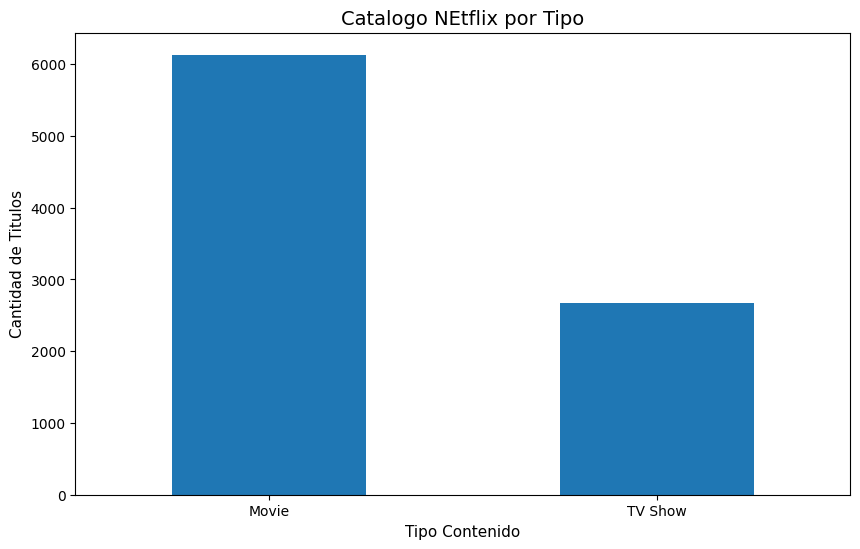

In [44]:
content_type.plot(
    kind='bar',
    title='Catalogo NEtflix por Tipo',
    xlabel='Tipo Contenido',
    ylabel='Cantidad de Titulos'
)
plt.xticks(rotation=0)
plt.show()

### Evolucion del Catalogo

In [45]:
titles_added_year = (ntflx_clean.dropna(subset=['added_year']).groupby(['added_year', 'type']).size().unstack(fill_value=0))
titles_added_year

type,Movie,TV Show
added_year,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


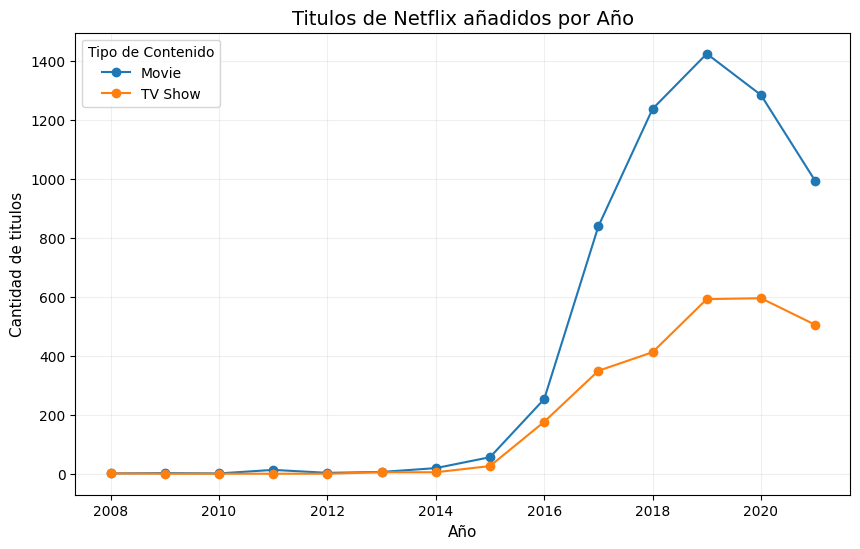

In [46]:
titles_added_year.plot(
    kind='line',
    marker='o',
    title='Titulos de Netflix añadidos por Año',
    xlabel='Año',
    ylabel='Cantidad de titulos'
)
plt.legend(title='Tipo de Contenido')
plt.grid(alpha=0.2)
plt.show()

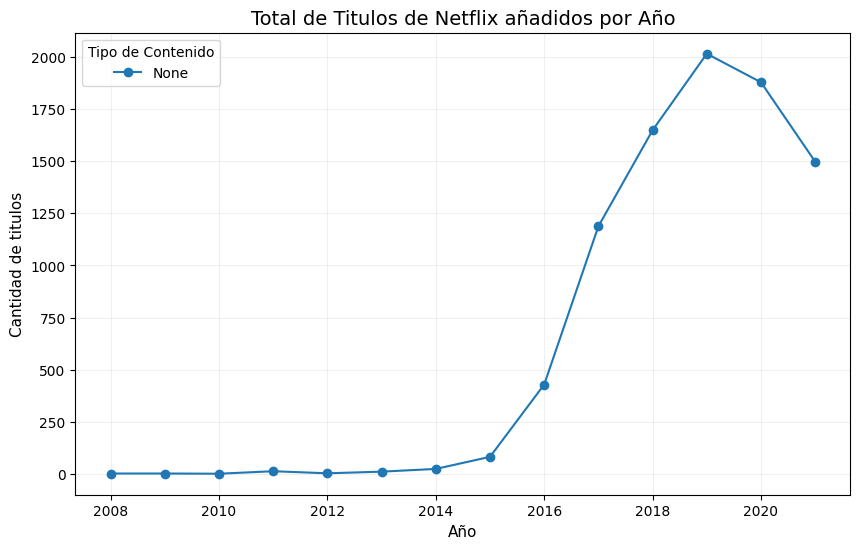

In [47]:
total_added_year = (
    ntflx_clean.dropna(subset=['added_year']).groupby('added_year').size())

total_added_year.plot(
    kind='line',
    marker='o',
    title='Total de Titulos de Netflix añadidos por Año',
    xlabel='Año',
    ylabel='Cantidad de titulos'
)
plt.legend(title='Tipo de Contenido')
plt.grid(alpha=0.2)
plt.show()

### Crecimiento del Catalogo

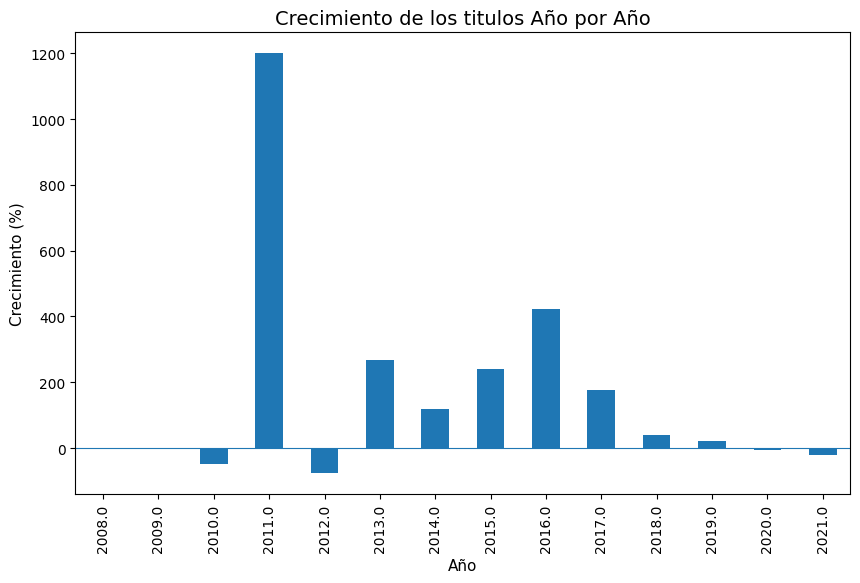

In [48]:
growth_year = (total_added_year.pct_change().mul(100).round(2))
growth_year.plot(
    kind='bar',
    title='Crecimiento de los titulos Año por Año',
    xlabel='Año',
    ylabel='Crecimiento (%)'
)

plt.axhline(0, linewidth=0.8)
plt.show()

**El tener valores negativos implica que Netflix agrego menos titulos ese Año**

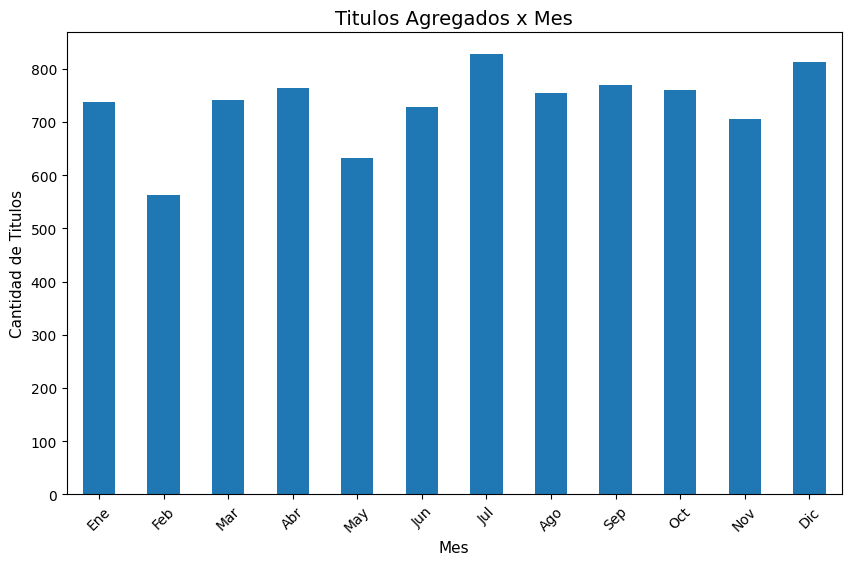

In [49]:
monthly_additions = (ntflx_clean.dropna(subset=['added_month']).groupby('added_month').size())
monthly_additions.plot(
    kind='bar',
    title='Titulos Agregados x Mes',
    xlabel='Mes',
    ylabel='Cantidad de Titulos'
)

plt.xticks(
    ticks=range(12),
    labels=[
        'Ene', 'Feb', 'Mar', 'Abr',
        'May', 'Jun', 'Jul', 'Ago',
        'Sep', 'Oct', 'Nov', 'Dic'
    ],
    rotation=45
)

plt.show()

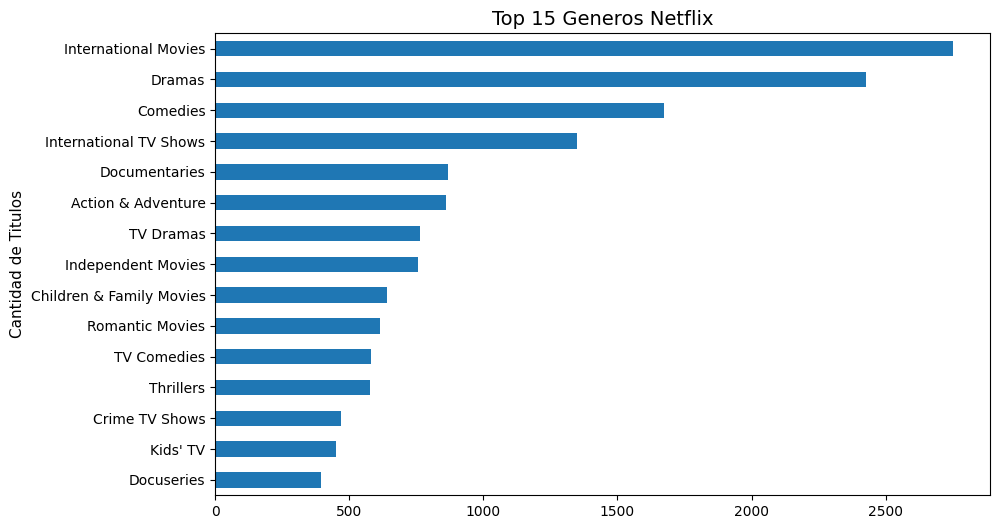

In [50]:
# Orden Generos
top_genres = (ntflx_genre['genre'].value_counts().head(15))
top_genres.sort_values().plot(
    kind='barh',
    title='Top 15 Generos Netflix',
    xlabel='Cantidad de Titulos',
    ylabel='Genero'
)
plt.show()

In [51]:
#Generos x tipo de contenido
genre_analysis = ntflx_genre.merge(ntflx_clean[['show_id', 'type']],on='show_id',how='left')
genre_by_type = pd.crosstab(
    genre_analysis['genre'],
    genre_analysis['type']
)

genre_by_type

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0
Classic & Cult TV,0,28
Classic Movies,116,0
Comedies,1674,0
Crime TV Shows,0,470


In [52]:
genre_by_type['Movie'].sort_values(
    ascending=False
).head(10)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: Movie, dtype: int64

In [53]:
genre_by_type['TV Show'].sort_values(
    ascending=False
).head(10)

genre
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: TV Show, dtype: int64

In [54]:
#Analisis de Rating
rating_counts = ntflx_clean['rating'].value_counts()
rating_counts

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
rating         7
TV-Y7-FV       6
UR             3
NC-17          3
Name: rating, dtype: int64

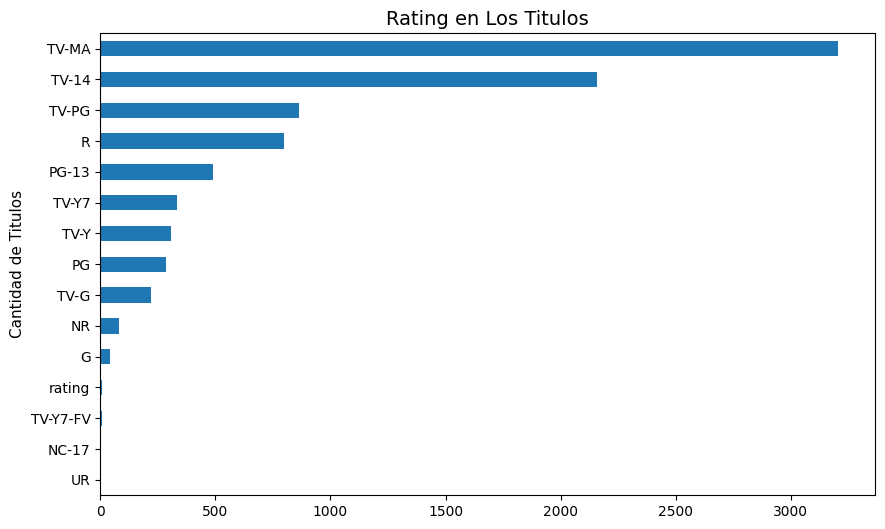

In [55]:
rating_counts.head(15).sort_values().plot(
    kind='barh',
    title='Rating en Los Titulos',
    xlabel='Cantidad de Titulos',
    ylabel='Rating'
)

plt.show()

In [56]:
#Rating x tipo
rating_by_type = pd.crosstab(
    ntflx_clean['rating'],
    ntflx_clean['type']
)

rating_by_type

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145


In [57]:
#Rating por pelicula
rating_by_type['Movie'].sort_values(ascending=False).head(10)

rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490
PG        287
TV-Y7     139
TV-Y      131
TV-G      126
NR         75
Name: Movie, dtype: int64

In [58]:
#Rating por Show de TV
rating_by_type['TV Show'].sort_values(ascending=False).head(10)

rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
rating         2
TV-Y7-FV       1
Name: TV Show, dtype: int64

### Analisis de Tiempo

In [59]:
ntflx_clean['years_to_netflix'].describe()

count    8783.000000
mean        4.697825
std         8.790808
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: years_to_netflix, dtype: float64

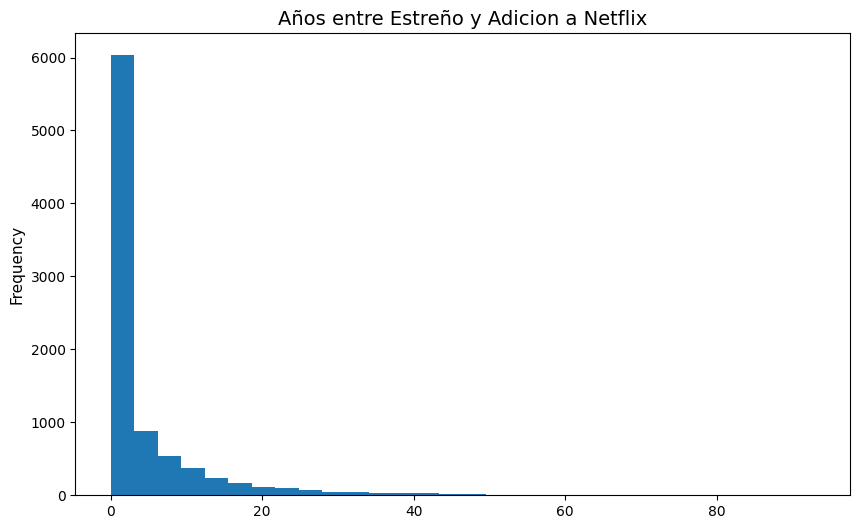

In [60]:
ntflx_clean['years_to_netflix'].plot(
    kind='hist',
    bins=30,
    title='Años entre Estreño y Adicion a Netflix',
    xlabel='Años a Netflix',
    ylabel='Cantidad de Titulos'
)

plt.show()

In [61]:
mean_years = (ntflx_clean['years_to_netflix'].mean())

median_years = (ntflx_clean['years_to_netflix'].median())

print(f"Media: {mean_years:.2f} years")
print(f"Mediana: {median_years:.2f} years")

Media: 4.70 years
Mediana: 1.00 years


In [62]:
years_by_type = (ntflx_clean.groupby('type')['years_to_netflix'].agg(['count','mean', 'median', 'min','max']).round(2))
years_by_type

,count,mean,median,min,max
type,,,,,
Movie,6129,5.73,2.0,0.0,75.0
TV Show,2654,2.31,0.0,0.0,93.0


In [63]:
age_groups = (ntflx_clean['content_age_group'].value_counts())
age_groups

Nuevo Lanzamiento    4826
Reciente             1833
Antiguo              1205
Catalogo              919
Unknown                24
Name: content_age_group, dtype: int64

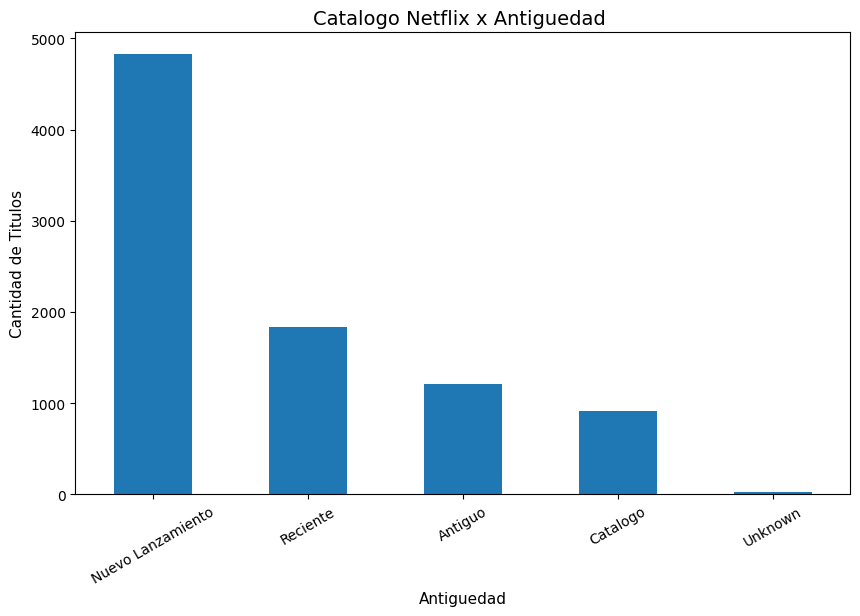

In [64]:
age_groups.plot(
    kind='bar',
    title='Catalogo Netflix x Antiguedad ',
    xlabel='Antiguedad',
    ylabel='Cantidad de Titulos'
)

plt.xticks(rotation=30)
plt.show()

In [65]:
age_groups_pct = (
    ntflx_clean['content_age_group']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

age_groups_pct

Nuevo Lanzamiento    54.80
Reciente             20.81
Antiguo              13.68
Catalogo             10.43
Unknown               0.27
Name: content_age_group, dtype: float64

### Analisis Geografico

In [66]:
country_analysis = ntflx_country[ntflx_country['country'] != 'Unknown'].copy()
top_countries = (country_analysis['country'].value_counts().head(20))

top_countries

United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Indonesia           90
Name: country, dtype: int64

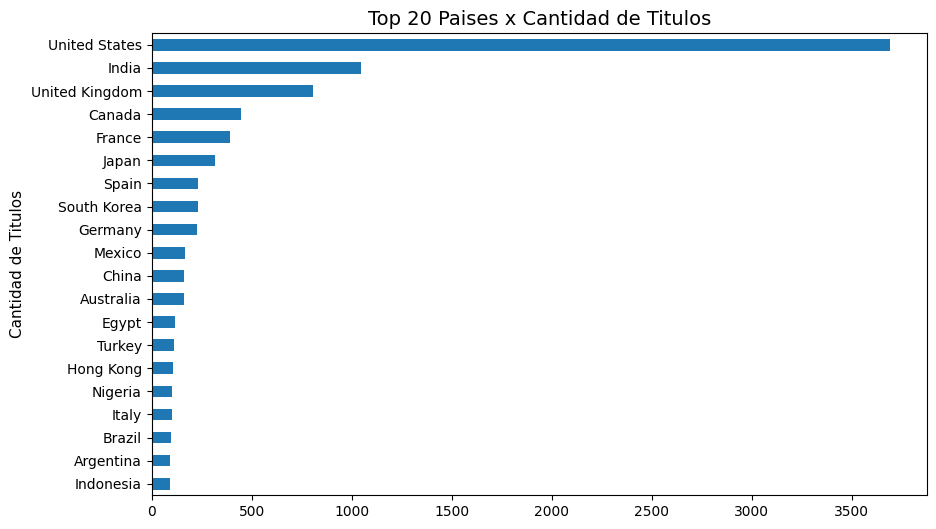

In [67]:
top_countries.sort_values().plot(
    kind='barh',
    title='Top 20 Paises x Cantidad de Titulos',
    xlabel='Cantidad de Titulos',
    ylabel='Pais'
)

plt.show()

In [68]:
#Pais x Tipo de contenido
country_analysis = country_analysis.merge(ntflx_clean[['show_id', 'type']],on='show_id',how='left')
country_type = pd.crosstab(country_analysis['country'],country_analysis['type'])
country_type['Movie'].sort_values(ascending=False).head(10)

country
United States     2752
India              962
United Kingdom     534
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: Movie, dtype: int64

In [69]:
country_type['TV Show'].sort_values(ascending=False).head(10)

country
United States     938
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Spain              61
Name: TV Show, dtype: int64

In [70]:
#Concentracion Geografica
country_counts = (country_analysis['country'].value_counts())

top_5_share = (country_counts.head(5).sum()/ country_counts.sum()* 100)

top_10_share = (country_counts.head(10).sum()/ country_counts.sum()* 100)

print(f"Top 5 Paises con mas participacion: {top_5_share:.2f}%")
print(f"Top 10 Paises con mas participacion: {top_10_share:.2f}%")

Top 5 Paises con mas participacion: 63.68%
Top 10 Paises con mas participacion: 75.42%


### Duracion Peliculas y series

In [71]:
# Duracion de Peliculas
movies = ntflx_clean[(ntflx_clean['type'] == 'Movie') & (ntflx_clean['duration_unit'] == 'Minutes')].copy()
movies['duration_value'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

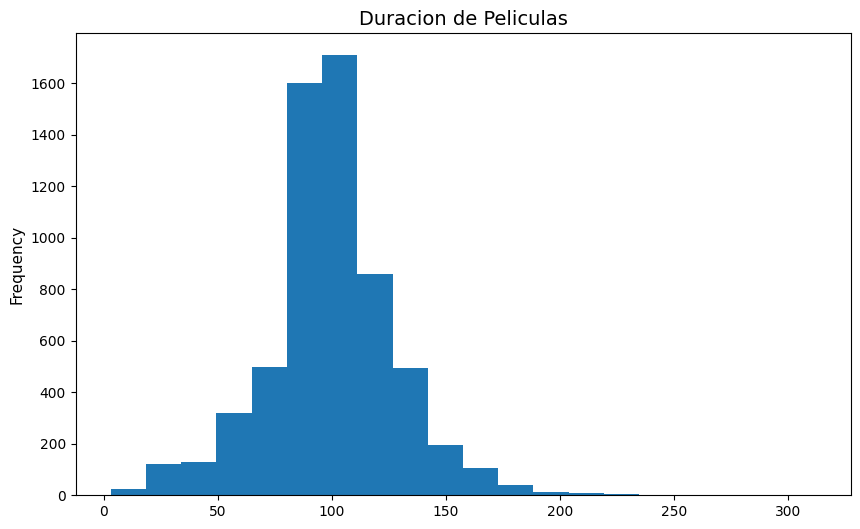

In [72]:
movies['duration_value'].plot(
    kind='hist',
    bins=20,
    title='Duracion de Peliculas',
    xlabel='Duracion (minutos)',
    ylabel='Cantidad de Peliculas'
)

plt.show()

In [73]:
# Duracion de series
tv_shows = ntflx_clean[(ntflx_clean['type'] == 'TV Show') & (ntflx_clean['duration_unit'] == 'Seasons')].copy()
tv_shows['duration_value'].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64

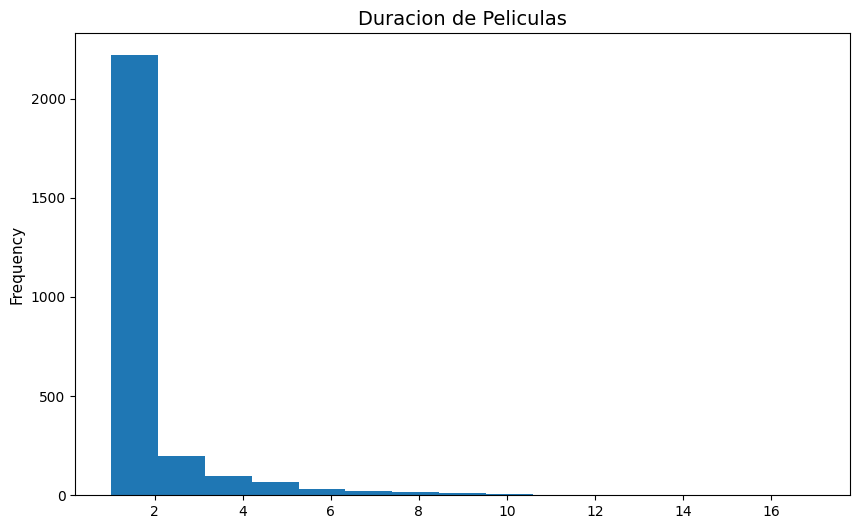

In [74]:
tv_shows['duration_value'].plot(
    kind='hist',
    bins=15,
    title='Duracion de Peliculas',
    xlabel='Duracion (minutos)',
    ylabel='Cantidad de Peliculas'
)

plt.show()

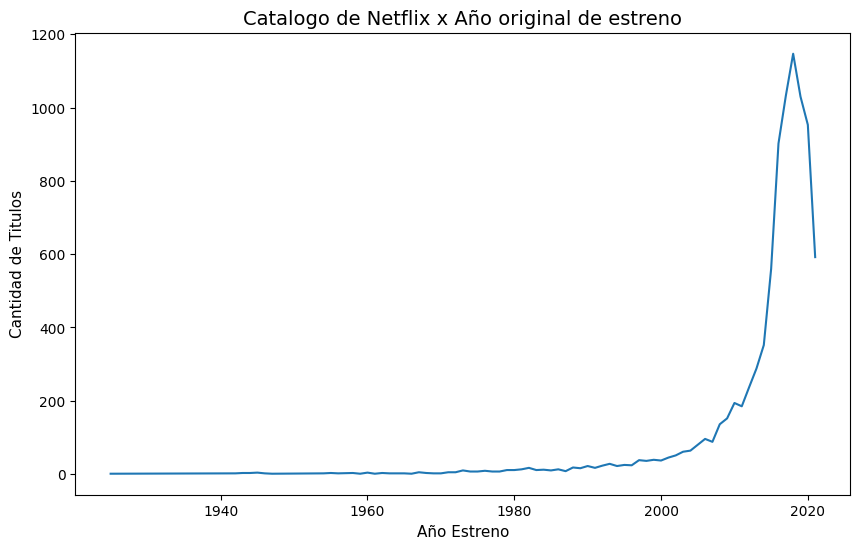

In [75]:
# Lanzamiento de contenidos
release_year_counts = (ntflx_clean['release_year'].value_counts().sort_index())
release_year_counts.plot(
    kind='line',
    title='Catalogo de Netflix x Año original de estreno',
    xlabel='Año Estreno',
    ylabel='Cantidad de Titulos'
)

plt.show()

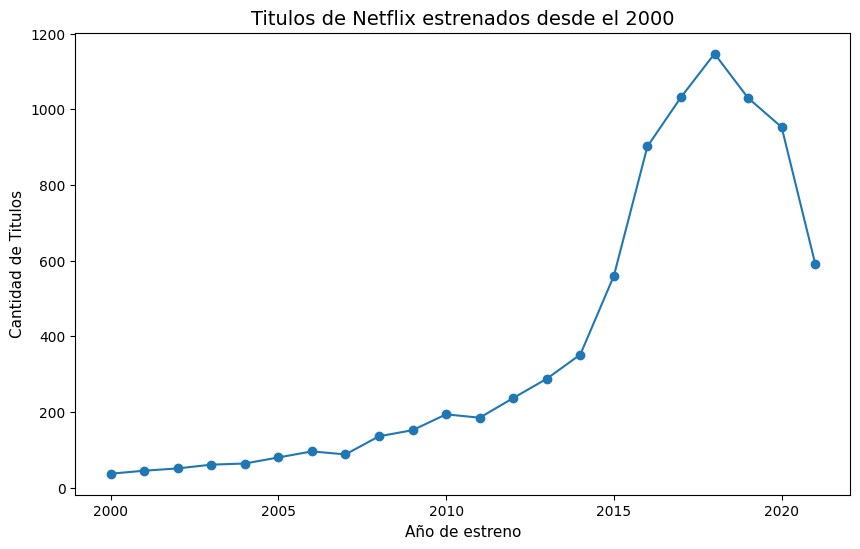

In [76]:
recent_release = (release_year_counts[release_year_counts.index >= 2000])

recent_release.plot(
    kind='line',
    marker='o',
    title='Titulos de Netflix estrenados desde el 2000',
    xlabel='Año de estreno',
    ylabel='Cantidad de Titulos'
)

plt.show()

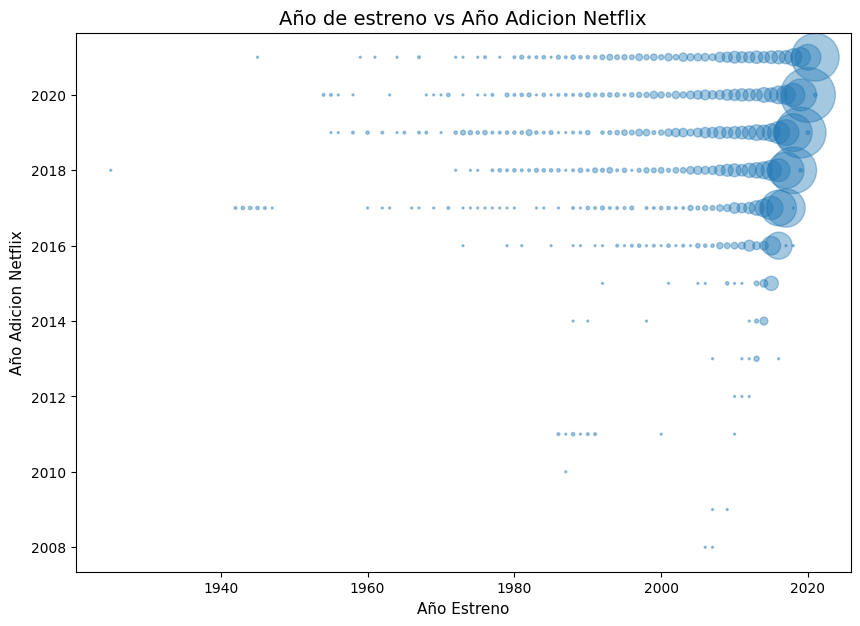

In [77]:
release_added = (ntflx_clean.dropna(subset=['release_year', 'added_year']).groupby(['release_year','added_year']).size().reset_index(name='titles'))
plt.figure(figsize=(10, 7))

plt.scatter(
    release_added['release_year'],
    release_added['added_year'],
    s=release_added['titles'] * 2,
    alpha=0.4
)

plt.title('Año de estreno vs Año Adicion Netflix')
plt.xlabel('Año Estreno')
plt.ylabel('Año Adicion Netflix')

plt.show()

In [78]:
age_by_type = pd.crosstab(ntflx_clean['content_age_group'],ntflx_clean['type'])
age_by_type

type,Movie,TV Show
content_age_group,,
Antiguo,1075,130
Catalogo,712,207
Nuevo Lanzamiento,3040,1786
Reciente,1302,531
Unknown,2,22


### Evolucion de Géneros

In [79]:
genre_time = ntflx_genre.merge(ntflx_clean[['show_id', 'added_year']],on='show_id',how='left')
top_5_genres = (ntflx_genre['genre'].value_counts().head(5).index)

top_5_genres

Index(['International Movies', 'Dramas', 'Comedies', 'International TV Shows',
       'Documentaries'],
      dtype='object')

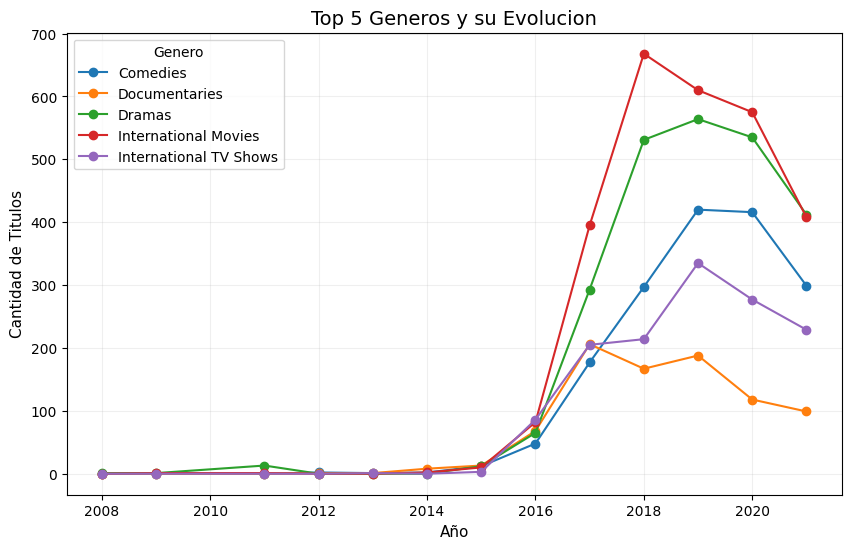

In [80]:
#Genero x año
genre_year = (
    genre_time[
        genre_time['genre'].isin(top_5_genres)
    ]
    .dropna(subset=['added_year'])
    .groupby(['added_year', 'genre'])
    .size()
    .unstack(fill_value=0)
)

genre_year.plot(
    kind='line',
    marker='o',
    title='Top 5 Generos y su Evolucion',
    xlabel='Año',
    ylabel='Cantidad de Titulos'
)

plt.legend(title='Genero')
plt.grid(alpha=0.2)
plt.show()

#### Analisis de crecimiento x Generos

In [81]:
genre_growth = genre_year.copy()

genre_growth['first_year'] = genre_growth.index.min()
genre_growth['last_year'] = genre_growth.index.max()

first_year = genre_year.index.min()
last_year = genre_year.index.max()

genre_change = pd.DataFrame({'first_year_titles': genre_year.loc[first_year],'last_year_titles': genre_year.loc[last_year]})
genre_change['absolute_change'] = (genre_change['last_year_titles'] -genre_change['first_year_titles'])
genre_change.sort_values('absolute_change',ascending=False)

,first_year_titles,last_year_titles,absolute_change
genre,,,
Dramas,1,412,411
International Movies,0,408,408
Comedies,0,299,299
International TV Shows,0,229,229
Documentaries,0,99,99


In [82]:
# Peliculas excesivamente largas
movies[movies['duration_value'] > 300][['title', 'duration_value']].sort_values('duration_value',ascending=False).head(20)

,title,duration_value
4253,Black Mirror: Bandersnatch,312


In [83]:
# Series con muchas temporadas
tv_shows[tv_shows['duration_value'] > 10][['title', 'duration_value']].sort_values('duration_value',ascending=False)

,title,duration_value
548,Grey's Anatomy,17
2423,Supernatural,15
4798,NCIS,15
1354,Heartland,13
4220,COMEDIANS of the world,13
7847,Red vs. Blue,13
4964,Trailer Park Boys,12
5412,Criminal Minds,12
6456,Cheers,11
6795,Frasier,11


### Hayazgos preliminares

#### Composicion del Catalogo

- Las peliculas representan aprox. 70% del catalogo.
- Las series (TV Shows) representan aprox. 30%

#### Crecimiento del Catalogo

- Cada año se hay mas peliculas que series

#### Distribucion Geografica

- Estados Unidos tiene mas titulos en las plataformas

#### Generos

- Las peliculas Internacionales son las que dominan el catalogo


#### Edad del contenido

- Desde el 2015 el catalogo ha tenido un gran crecimiento en peliculas y series tanto actuales como en años anteriores

---
## Business Analyst & Insights

**🎯 Objetivo:** Responder mediante datos a nuestras preguntas iniciales:

1. ¿Cómo ha evolucionado la estrategia de incorporación de contenido?
2. ¿Qué tipo de contenido domina y cómo está cambiando?
3. ¿Qué mercados y géneros tienen mayor presencia?
4. ¿Netflix está incorporando contenido reciente o depende de catálogo anterior?
5. ¿Qué oportunidades o patrones podemos identificar?

---

In [84]:
#Total de Titulos
total_titles = ntflx_clean['show_id'].nunique()
print(f"Titulos Totales: {total_titles:,}")
#Participacion de Peliculas y Series
content_share = (ntflx_clean['type'].value_counts(normalize=True).mul(100).round(2))

content_share

Titulos Totales: 8,807


Movie      69.62
TV Show    30.38
Name: type, dtype: float64

In [85]:
# Calculo de crecimiento interanual
content_growth = (ntflx_clean.dropna(subset=['added_year']).groupby(['added_year', 'type']).size().unstack(fill_value=0))
content_growth['Total'] = content_growth.sum(axis=1)
content_growth['YoY_Growth_%'] = (content_growth['Total'].pct_change().mul(100).round(2))

content_growth

type,Movie,TV Show,Total,YoY_Growth_%
added_year,,,,
2008.0,1,1,2,NaN
2009.0,2,0,2,0.00
2010.0,1,0,1,-50.00
2011.0,13,0,13,1200.00
2012.0,3,0,3,-76.92
2013.0,6,5,11,266.67
2014.0,19,5,24,118.18
2015.0,56,26,82,241.67
2016.0,253,176,429,423.17


In [86]:
content_growth.sort_values('YoY_Growth_%',ascending=False).head(10)

type,Movie,TV Show,Total,YoY_Growth_%
added_year,,,,
2011.0,13,0,13,1200.00
2016.0,253,176,429,423.17
2013.0,6,5,11,266.67
2015.0,56,26,82,241.67
2017.0,839,349,1188,176.92
2014.0,19,5,24,118.18
2018.0,1237,412,1649,38.80
2019.0,1424,592,2016,22.26
2009.0,2,0,2,0.00


In [87]:
content_growth.sort_values('YoY_Growth_%',ascending=True).head(10)

type,Movie,TV Show,Total,YoY_Growth_%
added_year,,,,
2012.0,3,0,3,-76.92
2010.0,1,0,1,-50.00
2021.0,993,505,1498,-20.28
2020.0,1284,595,1879,-6.80
2009.0,2,0,2,0.00
2019.0,1424,592,2016,22.26
2018.0,1237,412,1649,38.80
2014.0,19,5,24,118.18
2017.0,839,349,1188,176.92


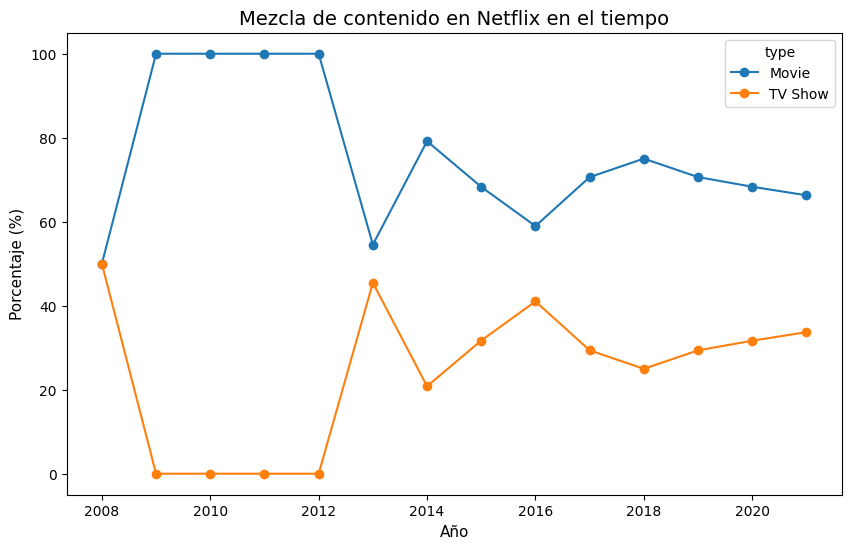

In [88]:
# Peliculas o Series crecen mas?
yearly_mix = (content_growth[['Movie', 'TV Show']].div(content_growth[['Movie', 'TV Show']].sum(axis=1),axis=0).mul(100).round(2))

yearly_mix.plot(
    kind='line',
    marker='o',
    title='Mezcla de contenido en Netflix en el tiempo',
    xlabel='Año',
    ylabel='Porcentaje (%)'
)

plt.show()

### Crecimiento Relativo de Series

In [89]:
movie_growth = (content_growth['Movie'].pct_change().mul(100))
tv_growth = (content_growth['TV Show'].pct_change().mul(100))
growth_comparison = pd.DataFrame({'Movie_Growth_%': movie_growth,'TV_Show_Growth_%': tv_growth}).round(2)

growth_comparison

,Movie_Growth_%,TV_Show_Growth_%
added_year,,
2008.0,NaN,NaN
2009.0,100.00,-100.00
2010.0,-50.00,NaN
2011.0,1200.00,NaN
2012.0,-76.92,NaN
2013.0,100.00,inf
2014.0,216.67,0.00
2015.0,194.74,420.00
2016.0,351.79,576.92


### Concentracion Geografica

In [90]:
country_counts = (ntflx_clean[ntflx_clean['country'] != 'Unknown']['country'].value_counts())
country_counts.head(10)

United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: country, dtype: int64

In [91]:
country_share = (country_counts.div(country_counts.sum()).mul(100).round(2))
country_share.head(10)

United States     35.33
India             12.19
United Kingdom     5.25
Japan              3.07
South Korea        2.49
Canada             2.27
Spain              1.82
France             1.55
Mexico             1.38
Egypt              1.33
Name: country, dtype: float64

### Top 5 VS Resto del mundo

In [92]:
top_5_country_share = country_share.head(5).sum()
top_10_country_share = country_share.head(10).sum()

print(f"Top 5 country share: {top_5_country_share:.2f}%")
print(f"Top 10 country share: {top_10_country_share:.2f}%")

Top 5 country share: 58.33%
Top 10 country share: 66.68%


### Analisis Internacionalizacion

In [93]:
countries_per_title = (ntflx_country[ntflx_country['country'] != 'Unknown'].groupby('show_id')['country'].nunique())

countries_per_title.describe()

count    8807.000000
mean        1.137618
std         0.759317
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        12.000000
Name: country, dtype: float64

In [94]:
ntflx_clean['num_countries'] = (ntflx_clean['show_id'].map(countries_per_title).fillna(0))
ntflx_clean['num_countries'].value_counts().sort_index()

0      831
1     6656
2      873
3      273
4      114
5       37
6       14
7        5
8        2
10       1
12       1
Name: num_countries, dtype: int64

### Contenido de produccion internacional

In [95]:
def classify_production_countries(n):
    if n == 0:
        return 'Unknown'
    elif n == 1:
        return 'Pais Unico'
    else:
        return 'Multi-Pais'

ntflx_clean['production_scope'] = (ntflx_clean['num_countries'].apply(classify_production_countries))
production_scope = (ntflx_clean['production_scope'].value_counts())

production_scope

Pais Unico    6656
Multi-Pais    1320
Unknown        831
Name: production_scope, dtype: int64

### Analisis de generos

In [96]:
genre_counts = (ntflx_genre['genre'].value_counts())
# Porcentaje de Generos
genre_share = (genre_counts.div(genre_counts.sum()).mul(100).round(2))

genre_share.head(15)

International Movies        14.24
Dramas                      12.56
Comedies                     8.66
International TV Shows       6.99
Documentaries                4.50
Action & Adventure           4.45
TV Dramas                    3.95
Independent Movies           3.91
Children & Family Movies     3.32
Romantic Movies              3.19
TV Comedies                  3.01
Thrillers                    2.99
Crime TV Shows               2.43
Kids' TV                     2.33
Docuseries                   2.04
Name: genre, dtype: float64

#### Concentracion de Generos

In [97]:
top_5_genre_share = genre_share.head(5).sum()

top_10_genre_share = genre_share.head(10).sum()

print(f"Porcentaje del Top 5: {top_5_genre_share:.2f}%")
print(f"Porcentaje del Top 10: {top_10_genre_share:.2f}%")

Porcentaje del Top 5: 46.95%
Porcentaje del Top 10: 65.77%


#### Generos x Peliculas vs Series

In [98]:
genre_type = (ntflx_genre.merge( ntflx_clean[['show_id', 'type']],on='show_id',how='left').groupby(['genre', 'type']).size().unstack(fill_value=0))
genre_type['Total'] = genre_type.sum(axis=1)

genre_type.sort_values('Total',ascending=False).head(15)

type,Movie,TV Show,Total
genre,,,
International Movies,2752,0,2752
Dramas,2427,0,2427
Comedies,1674,0,1674
International TV Shows,0,1351,1351
Documentaries,869,0,869
Action & Adventure,859,0,859
TV Dramas,0,763,763
Independent Movies,756,0,756
Children & Family Movies,641,0,641


#### Generos Especializados

In [99]:
genre_type['TV_Show_Share_%'] = (genre_type['TV Show'] /genre_type['Total'] *100).round(2)
genre_type.sort_values('TV_Show_Share_%',ascending=False).head(10)

type,Movie,TV Show,Total,TV_Show_Share_%
genre,,,,
TV Dramas,0,763,763,100.0
TV Horror,0,75,75,100.0
Science & Nature TV,0,92,92,100.0
Reality TV,0,255,255,100.0
Spanish-Language TV Shows,0,174,174,100.0
Korean TV Shows,0,151,151,100.0
Kids' TV,0,451,451,100.0
International TV Shows,0,1351,1351,100.0
Stand-Up Comedy & Talk Shows,0,56,56,100.0


In [100]:
genre_type.sort_values('TV_Show_Share_%',ascending=True).head(10)

type,Movie,TV Show,Total,TV_Show_Share_%
genre,,,,
Action & Adventure,859,0,859,0.0
Stand-Up Comedy,343,0,343,0.0
Sports Movies,219,0,219,0.0
Sci-Fi & Fantasy,243,0,243,0.0
Romantic Movies,616,0,616,0.0
Music & Musicals,375,0,375,0.0
Movies,57,0,57,0.0
International Movies,2752,0,2752,0.0
Independent Movies,756,0,756,0.0


### ¿Netflix Incorpora contenido Nuevo?

In [101]:
age_distribution = (ntflx_clean[ntflx_clean['content_age_group'] != 'Unknown']['content_age_group'].value_counts())

age_distribution_pct = (age_distribution.div(age_distribution.sum()).mul(100).round(2))

age_distribution_pct

Nuevo Lanzamiento    54.95
Reciente             20.87
Antiguo              13.72
Catalogo             10.46
Name: content_age_group, dtype: float64

#### Comparacion Antiguedad entre Peliculas y series

In [104]:
age_type = pd.crosstab(ntflx_clean['content_age_group'],ntflx_clean['type'],normalize='columns').mul(100).round(2)

age_type

type,Movie,TV Show
content_age_group,,
Antiguo,17.53,4.86
Catalogo,11.61,7.74
Nuevo Lanzamiento,49.58,66.74
Reciente,21.24,19.84
Unknown,0.03,0.82


#### Mediana vs promedio

In [105]:
years_summary = (ntflx_clean.groupby('type')['years_to_netflix']
    .agg(
        Mean='mean',
        Median='median',
        P25=lambda x: x.quantile(0.25),
        P75=lambda x: x.quantile(0.75)
    ).round(2))

years_summary

,Mean,Median,P25,P75
type,,,,
Movie,5.73,2.0,0.0,7.0
TV Show,2.31,0.0,0.0,2.0


#### Contenido Antiguo

In [106]:
legacy_titles = (ntflx_clean[ntflx_clean['years_to_netflix'] >= 20][
        ['title','type','release_year','added_year','years_to_netflix']]
    .sort_values('years_to_netflix',ascending=False))

legacy_titles.head(20)

,title,type,release_year,added_year,years_to_netflix
4250,Pioneers: First Women Filmmakers*,TV Show,1925,2018.0,93.0
1331,Five Came Back: The Reference Films,TV Show,1945,2021.0,76.0
7790,Prelude to War,Movie,1942,2017.0,75.0
8205,The Battle of Midway,Movie,1942,2017.0,75.0
8763,WWII: Report from the Aleutians,Movie,1943,2017.0,74.0
8739,Why We Fight: The Battle of Russia,Movie,1943,2017.0,74.0
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943,2017.0,74.0
8419,The Memphis Belle: A Story of a\nFlying Fortress,Movie,1944,2017.0,73.0
8436,The Negro Soldier,Movie,1944,2017.0,73.0
8640,Tunisian Victory,Movie,1944,2017.0,73.0


### Analisis de duración

In [107]:
#Peliculas
movie_duration_summary = (movies['duration_value'].describe().round(2))

movie_duration_summary

count    6131.00
mean       99.56
std        28.29
min         3.00
25%        87.00
50%        98.00
75%       114.00
max       312.00
Name: duration_value, dtype: float64

In [108]:
#Series
tv_duration_summary = (tv_shows['duration_value'].describe().round(2))

tv_duration_summary

count    2676.00
mean        1.76
std         1.58
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        17.00
Name: duration_value, dtype: float64

#### Clasificacion duracion de peliculas

In [111]:
def classify_movie_duration(minutes):
    if pd.isna(minutes):
        return 'Unknown'
    elif minutes < 60:
        return 'Corto (<60 min)'
    elif minutes < 90:
        return 'Medio (60-89 min)'
    elif minutes <= 120:
        return 'Estandar (90-120 min)'
    else:
        return 'Largo (>120 min)'

movies['duration_group'] = (movies['duration_value'].apply(classify_movie_duration))
movies['duration_group'].value_counts()

Estandar (90-120 min)    3148
Medio (60-89 min)        1383
Largo (>120 min)         1142
Corto (<60 min)           458
Name: duration_group, dtype: int64

#### Clasificacion numero de temporadas

In [112]:
def classify_seasons(seasons):
    if pd.isna(seasons):
        return 'Unknown'
    elif seasons == 1:
        return 'Limitado / 1 Season'
    elif seasons <= 3:
        return 'Temporada corta (2-3)'
    elif seasons <= 6:
        return 'Media Temporada (4-6)'
    else:
        return 'Muchas temporadas (7+)'


tv_shows['season_group'] = (tv_shows['duration_value'].apply(classify_seasons))
tv_shows['season_group'].value_counts()

Limitado / 1 Season       1793
Temporada corta (2-3)      624
Media Temporada (4-6)      193
Muchas temporadas (7+)      66
Name: season_group, dtype: int64

### Analisis Evolucion Contenido Internacional

In [116]:
international_trend = (ntflx_country[ntflx_country['country'] != 'Unknown'].merge(ntflx_clean[['show_id', 'added_year']], on='show_id', how='left'))
country_year = (international_trend.dropna(subset=['added_year']).groupby('added_year')['country'].nunique())

country_year

added_year
2008.0     1
2009.0     2
2010.0     1
2011.0     5
2012.0     2
2013.0     4
2014.0    10
2015.0    16
2016.0    52
2017.0    77
2018.0    83
2019.0    73
2020.0    77
2021.0    72
Name: country, dtype: int64

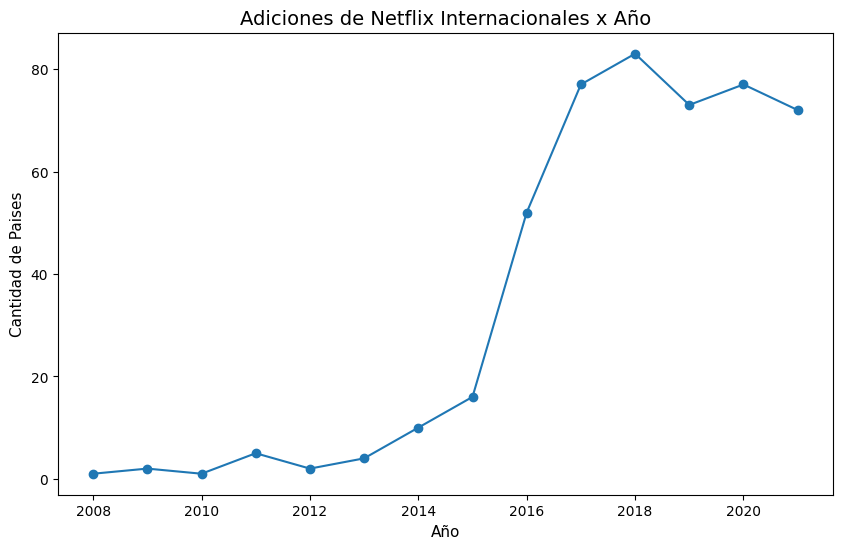

In [118]:
country_year.plot(
    kind='line',
    marker='o',
    title='Adiciones de Netflix Internacionales x Año',
    xlabel='Año',
    ylabel='Cantidad de Paises'
)

plt.show()

### Analisis Ede diversidad geografica

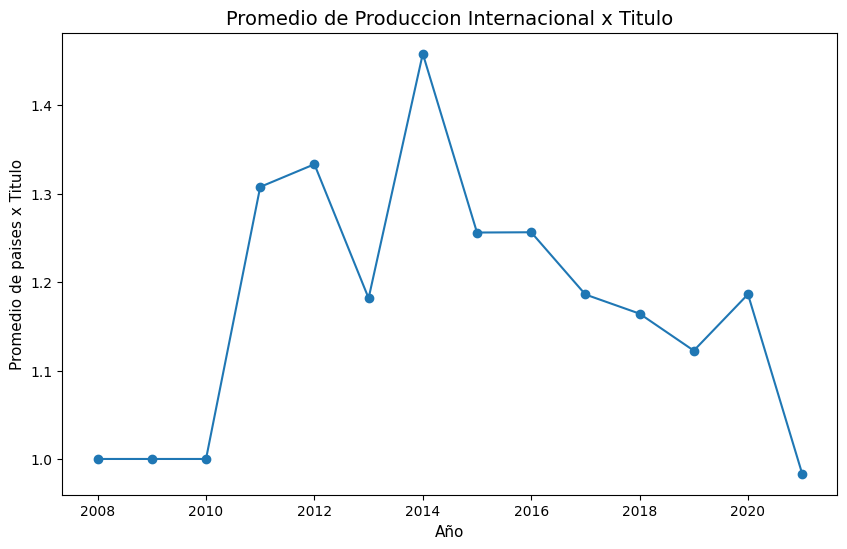

In [120]:
geographic_diversity = (ntflx_clean.dropna(subset=['added_year']).groupby('added_year')['num_countries'].mean())

geographic_diversity.plot(
    kind='line',
    marker='o',
    title='Promedio de Produccion Internacional x Titulo',
    xlabel='Año',
    ylabel='Promedio de paises x Titulo'
)

plt.show()

In [125]:
#Tabla de Tendencias
trend_table = ( ntflx_clean.dropna(subset=['added_year']).groupby(['added_year', 'type']).agg(titles=('show_id', 'nunique'),
        avg_years_to_netflix=('years_to_netflix', 'mean')).reset_index())

trend_table['avg_years_to_netflix'] = (trend_table['avg_years_to_netflix'].round(2))

trend_table.head(15)

,added_year,type,titles,avg_years_to_netflix
0,2008.0,Movie,1,2.00
1,2008.0,TV Show,1,1.00
2,2009.0,Movie,2,1.00
3,2010.0,Movie,1,23.00
4,2011.0,Movie,13,19.92
5,2012.0,Movie,3,1.00
6,2013.0,Movie,6,0.33
7,2013.0,TV Show,5,1.75
8,2014.0,Movie,19,1.53
9,2014.0,TV Show,5,8.60


### Hayazgos del negocio

#### Composicion del Catalogo (Business Findings)

##### Observacion
- Las peliculas representan aprox. 70% del catalogo mientras que las series (TV Shows) representan aprox. 30%

##### Insight
- En el catalogo predominan las peliculas.

##### Implicacion en el negocio
- El balance entre Peliculas en Series indica como el portafolio de Netflix se compone.

---

#### Crecimiento del Catalogo

##### Observacion
- Las peliculas reprecentan un 80% del crecimiento en el catalogo

##### Insight
- El catalogo de series esta bastante por debajo a comparacion de las peliculas.

##### Implicacion en el negocio
- El catalogo esta  mas orientado a peliculas

---

#### Distribucion Geografica

##### Observacion
- Estados Unidos representa un mayor volumen en el catalogo.

##### Insight
- Estados Unidos tiene el mayor porcentaje de contenido en el catálogo, lo que indica una fuerte presencia de producciones estadounidenses dentro de la plataforma.

##### Implicacion en el negocio
- La alta concentración de contenido estadounidense puede ayudar a mantener una oferta atractiva para este mercado, pero también representa una oportunidad para diversificar el catálogo con contenido de otras regiones y atraer nuevos segmentos de usuarios.

---

#### Generos

##### Observacion
- Las peliculas internacionales y Dramas son los generos mas vistos. 

##### Insight
-  La alta presencia de películas internacionales y dramas indica que Netflix mantiene una oferta orientada tanto a contenido de alcance global como a géneros con una amplia variedad de producciones.

##### Implicacion en el negocio
- Netflix puede aprovechar la popularidad de estos géneros para fortalecer la retención de usuarios, mientras utiliza contenido de otros géneros para diversificar la oferta y atender diferentes preferencias de audiencia.